[*********************100%***********************]  1 of 1 completed


Walk‑forward validation results:
Fold 1: RMSE = 3.4434, R² = 0.7750
Fold 2: RMSE = 2.0246, R² = 0.7534
Fold 3: RMSE = 3.2727, R² = 0.9193
Fold 4: RMSE = 5.1755, R² = 0.8402
Fold 5: RMSE = 5.3538, R² = 0.6613

Average metrics across folds:
MAE: 2.7869
RMSE: 3.8540
MAPE: 1.73%
R²: 0.7899


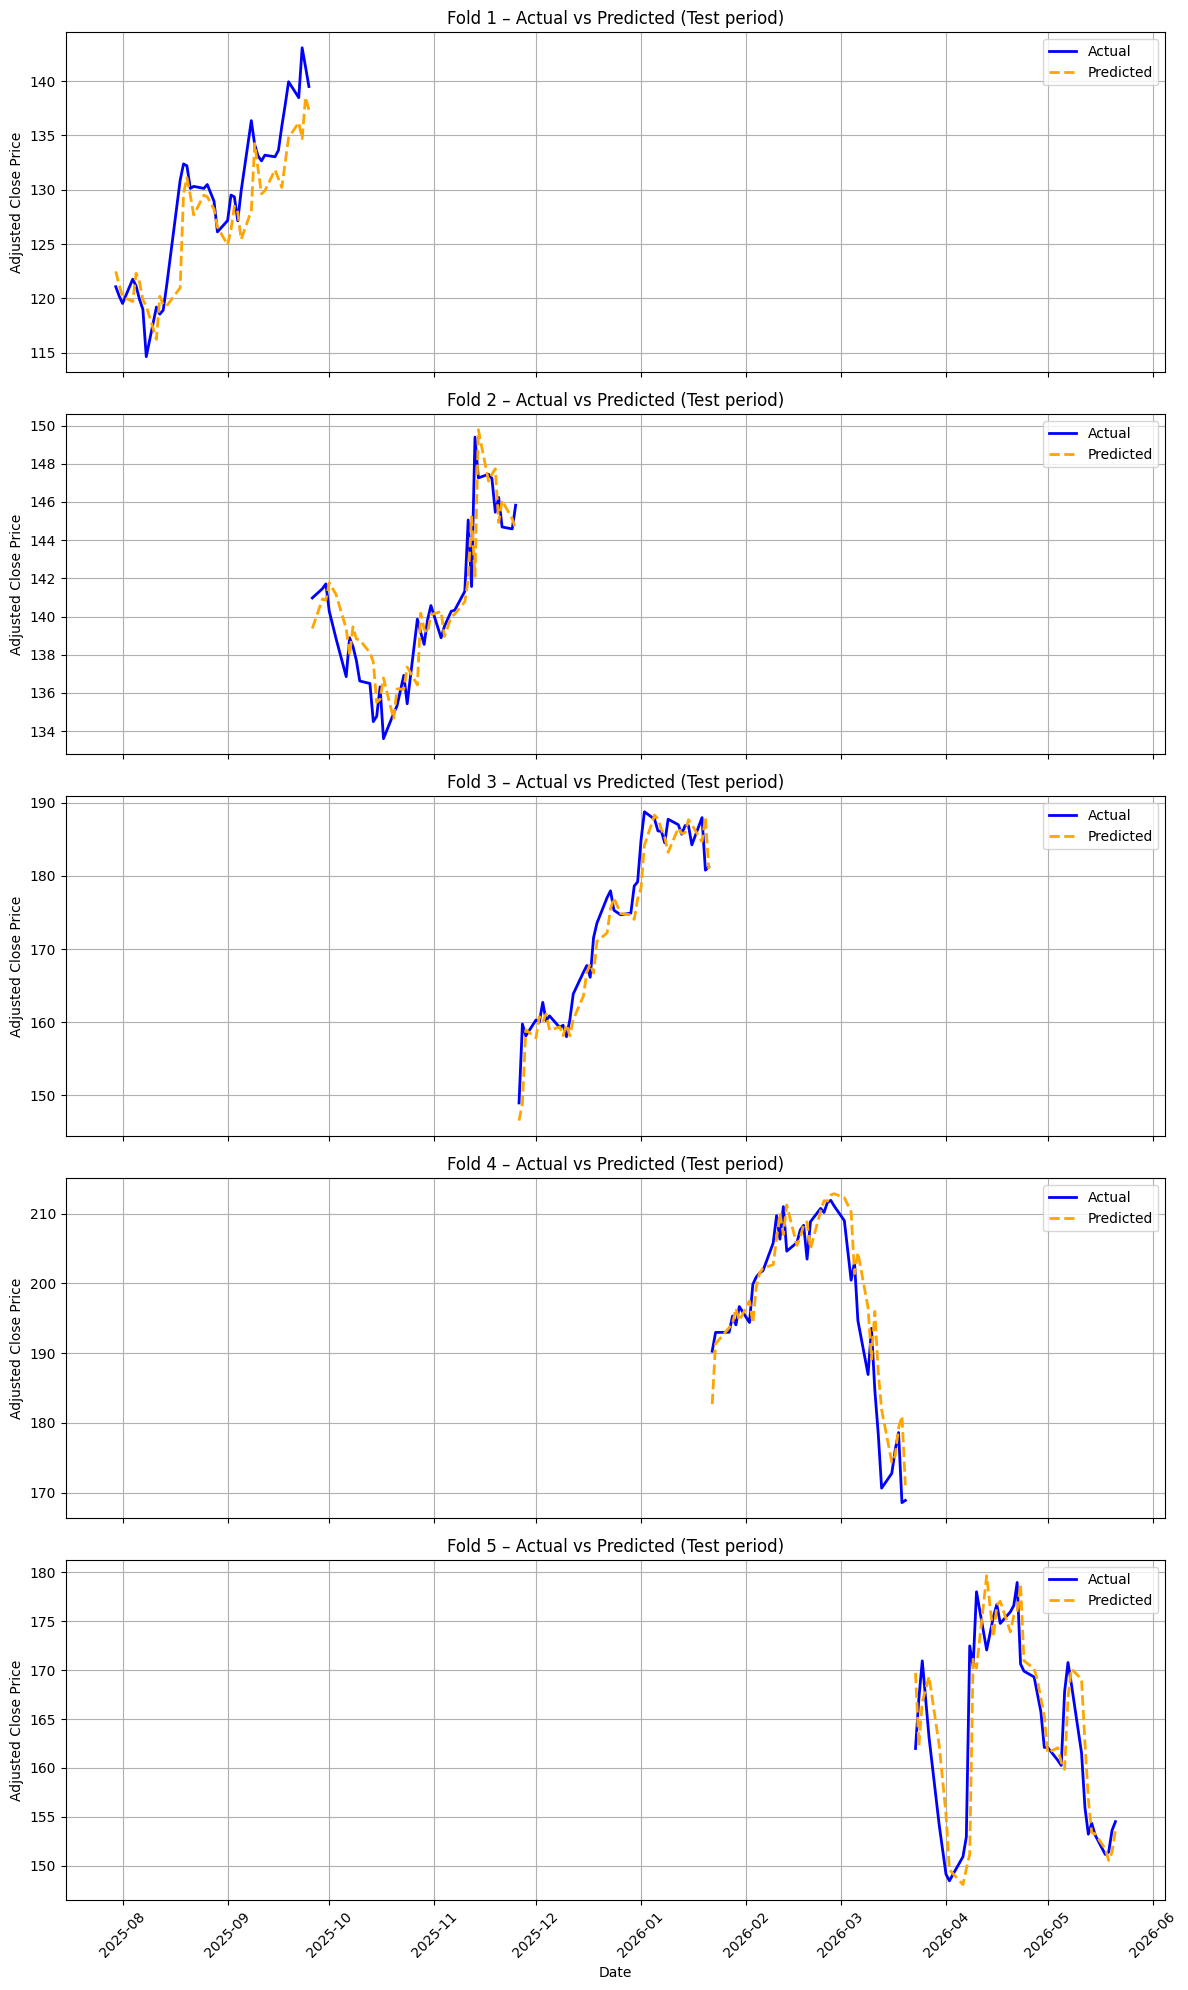

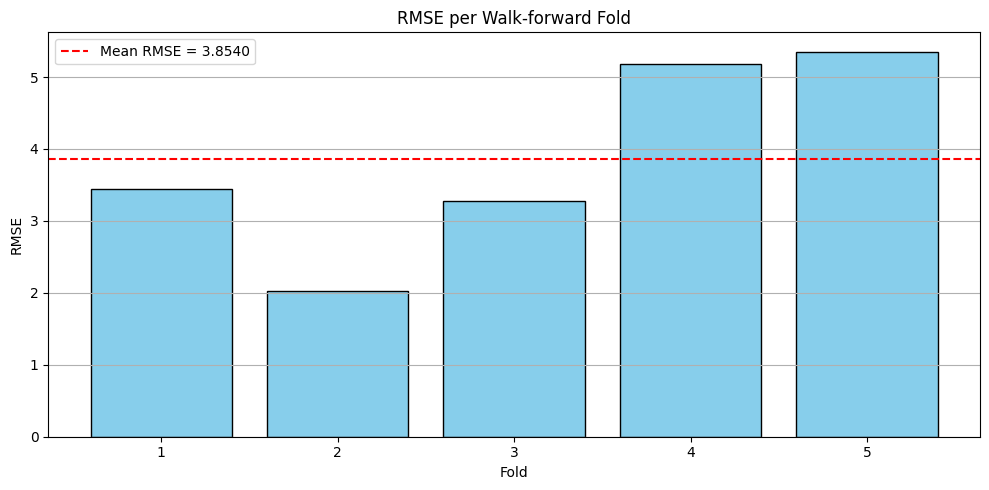


Next 5 trading day predictions:
2026-05-22: 154.54
2026-05-25: 154.32
2026-05-26: 154.05
2026-05-27: 153.87
2026-05-28: 153.73


/home/akshit/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/akshit/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/akshit/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/akshit/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/akshit/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


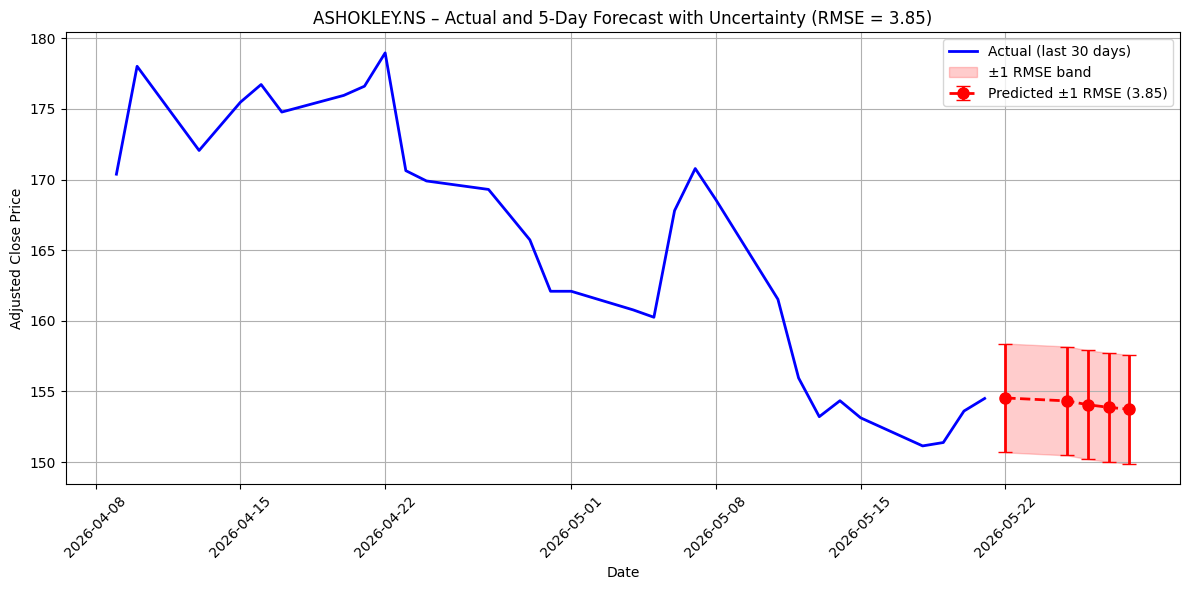

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ------------------------------
# 1. Load and prepare data
# ------------------------------
ticker = "ASHOKLEY.NS"
df_raw = yf.download(ticker, period="1y", auto_adjust=False)[["Adj Close"]]

# Flatten multi-index columns
df_raw.columns = df_raw.columns.get_level_values(0)


df = df_raw.copy()
for i in range(1, 10, 2):
    df[f'lag_{i}'] = df['Adj Close'].shift(i)

def compute_RSI(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window-1, adjust=False).mean()
    avg_loss = loss.ewm(com=window-1, adjust=False).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = compute_RSI(df['lag_1'])
df.dropna(inplace=True)

X = df.drop('Adj Close', axis=1)
y = df['Adj Close']

# ------------------------------
# 2. Define evaluation metrics
# ------------------------------
def evaluate(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape": (np.abs((y_true - y_pred) / y_true)).mean() * 100,
        "r2": r2_score(y_true, y_pred)
    }

# ------------------------------
# 3. Walk‑forward validation
# ------------------------------
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_metrics = []
fold_predictions = []  # store (y_test, y_pred) for later plots

print("Walk‑forward validation results:")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Pipeline: scaling + linear regression
    pipeline = Pipeline([
        ('model', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    metrics = evaluate(y_test, y_pred)
    fold_metrics.append(metrics)
    fold_predictions.append((y_test, y_pred))
    
    print(f"Fold {fold+1}: RMSE = {metrics['rmse']:.4f}, R² = {metrics['r2']:.4f}")

# Average metrics across folds
avg_metrics = {key: np.mean([m[key] for m in fold_metrics]) for key in fold_metrics[0]}
print("\nAverage metrics across folds:")
print(f"MAE: {avg_metrics['mae']:.4f}")
print(f"RMSE: {avg_metrics['rmse']:.4f}")
print(f"MAPE: {avg_metrics['mape']:.2f}%")
print(f"R²: {avg_metrics['r2']:.4f}")

# ------------------------------
# 4. Visualise predictions for each fold
# ------------------------------
fig, axes = plt.subplots(n_splits, 1, figsize=(12, 4*n_splits), sharex=True)
if n_splits == 1:
    axes = [axes]

for i, (y_test, y_pred) in enumerate(fold_predictions):
    ax = axes[i]
    ax.plot(y_test.index, y_test.values, label='Actual', linewidth=2, color='blue')
    ax.plot(y_test.index, y_pred, label='Predicted', linestyle='--', linewidth=2, color='orange')
    ax.set_title(f'Fold {i+1} – Actual vs Predicted (Test period)')
    ax.set_ylabel('Adjusted Close Price')
    ax.legend()
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Optional: summary bar chart of RMSE per fold
plt.figure(figsize=(10, 5))
rmse_vals = [m['rmse'] for m in fold_metrics]
plt.bar(range(1, n_splits+1), rmse_vals, color='skyblue', edgecolor='black')
plt.axhline(y=np.mean(rmse_vals), color='red', linestyle='--', label=f'Mean RMSE = {np.mean(rmse_vals):.4f}')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('RMSE per Walk‑forward Fold')
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# ------------------------------
# 5. Train final model on all data for recursive forecasting
# ------------------------------
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
final_pipeline.fit(X, y)

# ------------------------------
# 6. Recursive prediction for next 5 days
# ------------------------------
prices = df_raw['Adj Close'].tolist()
last_date = df_raw.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=5)

predictions = []
feature_columns = X.columns.tolist()

for _ in range(5):
    if len(prices) < 9:
        print("Error: Not enough historical prices for features.")
        break

    lag_1 = prices[-1]
    lag_3 = prices[-3]
    lag_5 = prices[-5]
    lag_7 = prices[-7]
    lag_9 = prices[-9]

    price_series = pd.Series(prices)
    rsi_val = compute_RSI(price_series).iloc[-1]

    feature_dict = {
        'lag_1': lag_1,
        'lag_3': lag_3,
        'lag_5': lag_5,
        'lag_7': lag_7,
        'lag_9': lag_9,
        'RSI': rsi_val
    }
    features = np.array([[feature_dict[col] for col in feature_columns]])

    next_price = final_pipeline.predict(features)[0]
    predictions.append(next_price)
    prices.append(next_price)

print("\nNext 5 trading day predictions:")
for date, price in zip(future_dates, predictions):
    print(f"{date.strftime('%Y-%m-%d')}: {price:.2f}")

# ------------------------------
# 7. Plot last 30 actual days + 5‑day forecast with uncertainty
# ------------------------------
rmse = avg_metrics['rmse']  # Use average RMSE from walk‑forward as error estimate

plt.figure(figsize=(12, 6))
plt.plot(df_raw.index[-30:], df_raw['Adj Close'].iloc[-30:],
         label='Actual (last 30 days)', color='blue', linewidth=2)

# Plot predictions with error bars
plt.errorbar(future_dates, predictions, yerr=rmse, fmt='ro--',
             capsize=5, markersize=8, linewidth=2,
             label=f'Predicted ±1 RMSE ({rmse:.2f})')

# Optional: add shaded region for confidence band
plt.fill_between(future_dates,
                 [p - rmse for p in predictions],
                 [p + rmse for p in predictions],
                 color='red', alpha=0.2, label='±1 RMSE band')

plt.title(f'{ticker} – Actual and 5‑Day Forecast with Uncertainty (RMSE = {rmse:.2f})')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[*********************100%***********************]  9 of 9 completed


Data shape: (11142, 6)
        Date       Ticker  Adj Close       Open       High        Low
0 2021-05-21  ASHOKLEY.NS  57.345348  63.000000  63.424999  61.924999
1 2021-05-24  ASHOKLEY.NS  57.139648  62.750000  63.224998  62.224998
2 2021-05-25  ASHOKLEY.NS  57.756760  62.750000  64.425003  62.750000
3 2021-05-26  ASHOKLEY.NS  57.368206  63.224998  63.875000  62.599998
4 2021-05-27  ASHOKLEY.NS  57.779617  62.900002  63.500000  62.525002
After feature engineering, shape: (9342, 42)

Train size: 8397, Test size: 936
Train dates: 2022-03-09T00:00:00 to 2025-12-16T00:00:00
Test dates:  2025-12-17T00:00:00 to 2026-05-20T00:00:00

Training Ridge...
Training Lasso...
Training LightGBM...

Model Performance on Test Set

Ridge:
  MAE:  23.7877
  RMSE: 36.7818
  MAPE: 1.99%
  R²:   0.9979

Lasso:
  MAE:  23.3112
  RMSE: 35.7425
  MAPE: 1.95%
  R²:   0.9980

LightGBM:
  MAE:  26.9466
  RMSE: 39.4239
  MAPE: 2.69%
  R²:   0.9975

Ensemble:
  MAE:  23.7116
  RMSE: 36.4504
  MAPE: 1.97%
  R²:   0.

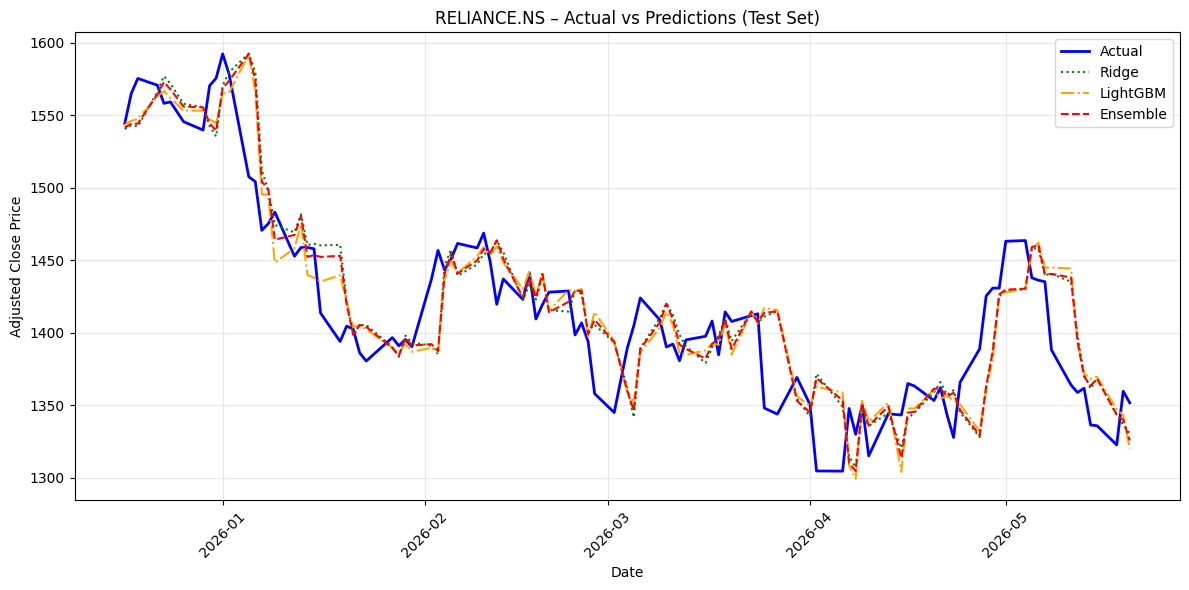

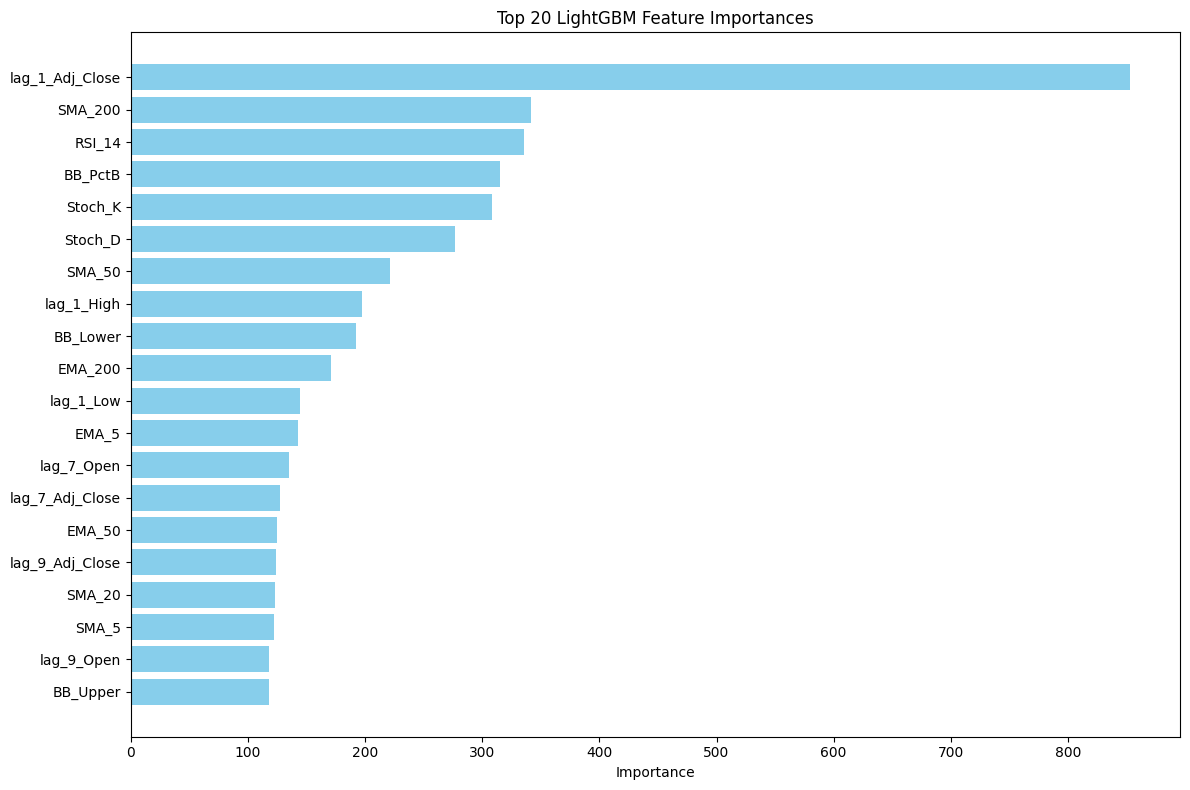


Recursive 5-day forecasts using ensemble model
Ensemble RMSE on test set: 36.4504

RELIANCE.NS – Next 5 trading-day predictions:
  2026-05-22: 1356.78
  2026-05-25: 1359.03
  2026-05-26: 1357.56
  2026-05-27: 1357.05
  2026-05-28: 1355.87

TCS.NS – Next 5 trading-day predictions:
  2026-05-22: 2324.65
  2026-05-25: 2325.55
  2026-05-26: 2324.31
  2026-05-27: 2323.47
  2026-05-28: 2326.62

HDFCBANK.NS – Next 5 trading-day predictions:
  2026-05-22: 760.60
  2026-05-25: 766.49
  2026-05-26: 770.97
  2026-05-27: 775.68
  2026-05-28: 781.15

INFY.NS – Next 5 trading-day predictions:
  2026-05-22: 1190.28
  2026-05-25: 1193.47
  2026-05-26: 1195.91
  2026-05-27: 1197.09
  2026-05-28: 1198.90

ICICIBANK.NS – Next 5 trading-day predictions:
  2026-05-22: 1243.90
  2026-05-25: 1246.52
  2026-05-26: 1247.61
  2026-05-27: 1248.72
  2026-05-28: 1249.65

HINDUNILVR.NS – Next 5 trading-day predictions:
  2026-05-22: 2186.67
  2026-05-25: 2187.83
  2026-05-26: 2186.59
  2026-05-27: 2186.67
  2026-0

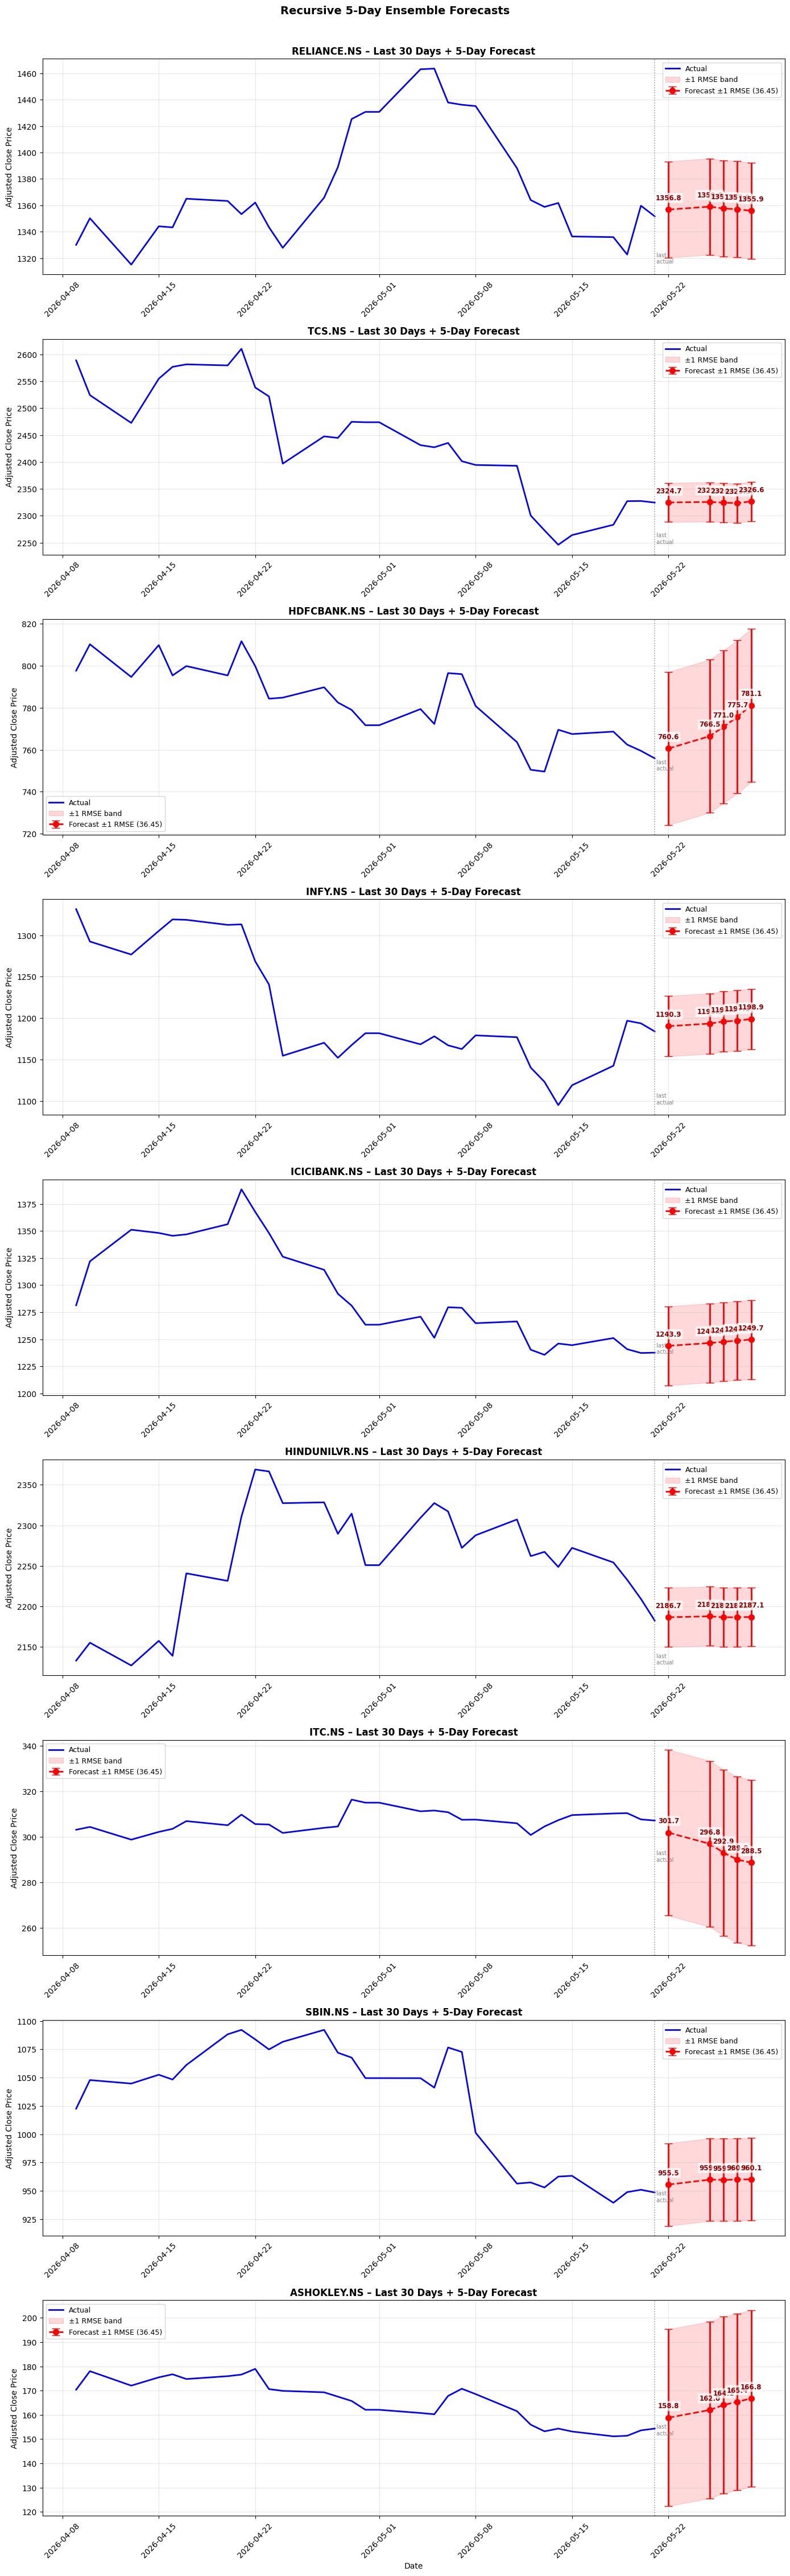


Walk-Forward Validation  (5 folds)

Fold 1  (train rows: 1,558  |  test rows: 1,555)
  Model               MAE       RMSE       MAPE       R²
  ----------------------------------------------------
  Ridge           28.0378    46.6244      1.67%   0.9986
  Lasso           26.3971    45.3720      1.51%   0.9987
  LightGBM       210.0685   241.4059     22.91%   0.9629
  Ensemble        79.3855    91.9473      7.97%   0.9946

Fold 2  (train rows: 3,113  |  test rows: 1,555)
  Model               MAE       RMSE       MAPE       R²
  ----------------------------------------------------
  Ridge           20.4002    29.1000      1.58%   0.9920
  Lasso           19.9492    28.7440      1.54%   0.9922
  LightGBM        34.1517    48.5484      2.51%   0.9777
  Ensemble        22.1129    31.7636      1.69%   0.9905

Fold 3  (train rows: 4,668  |  test rows: 1,555)
  Model               MAE       RMSE       MAPE       R²
  ----------------------------------------------------
  Ridge           26.3

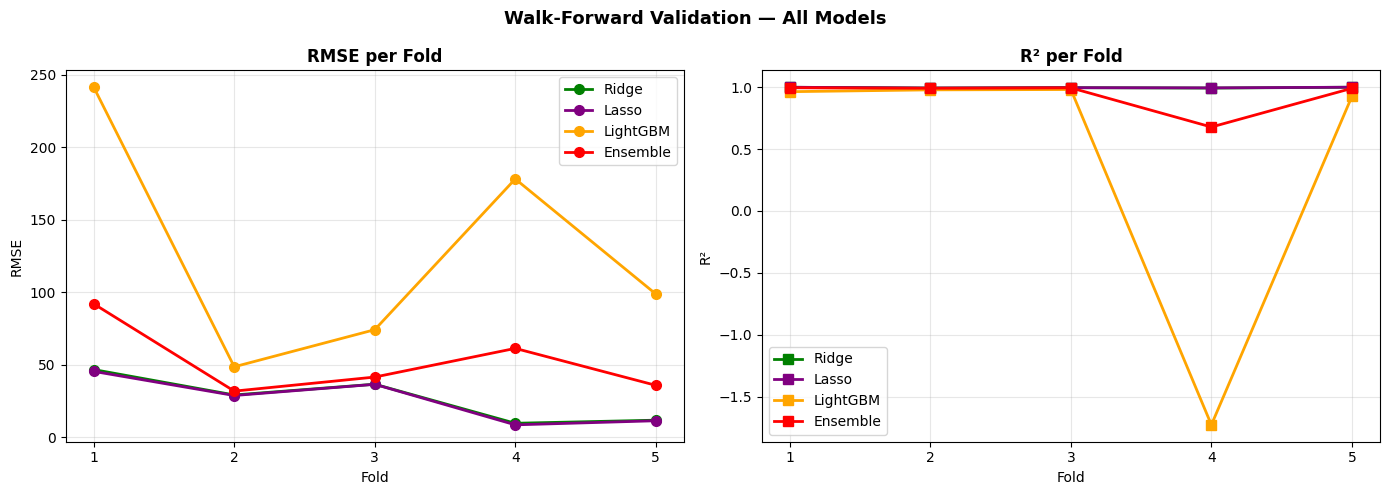

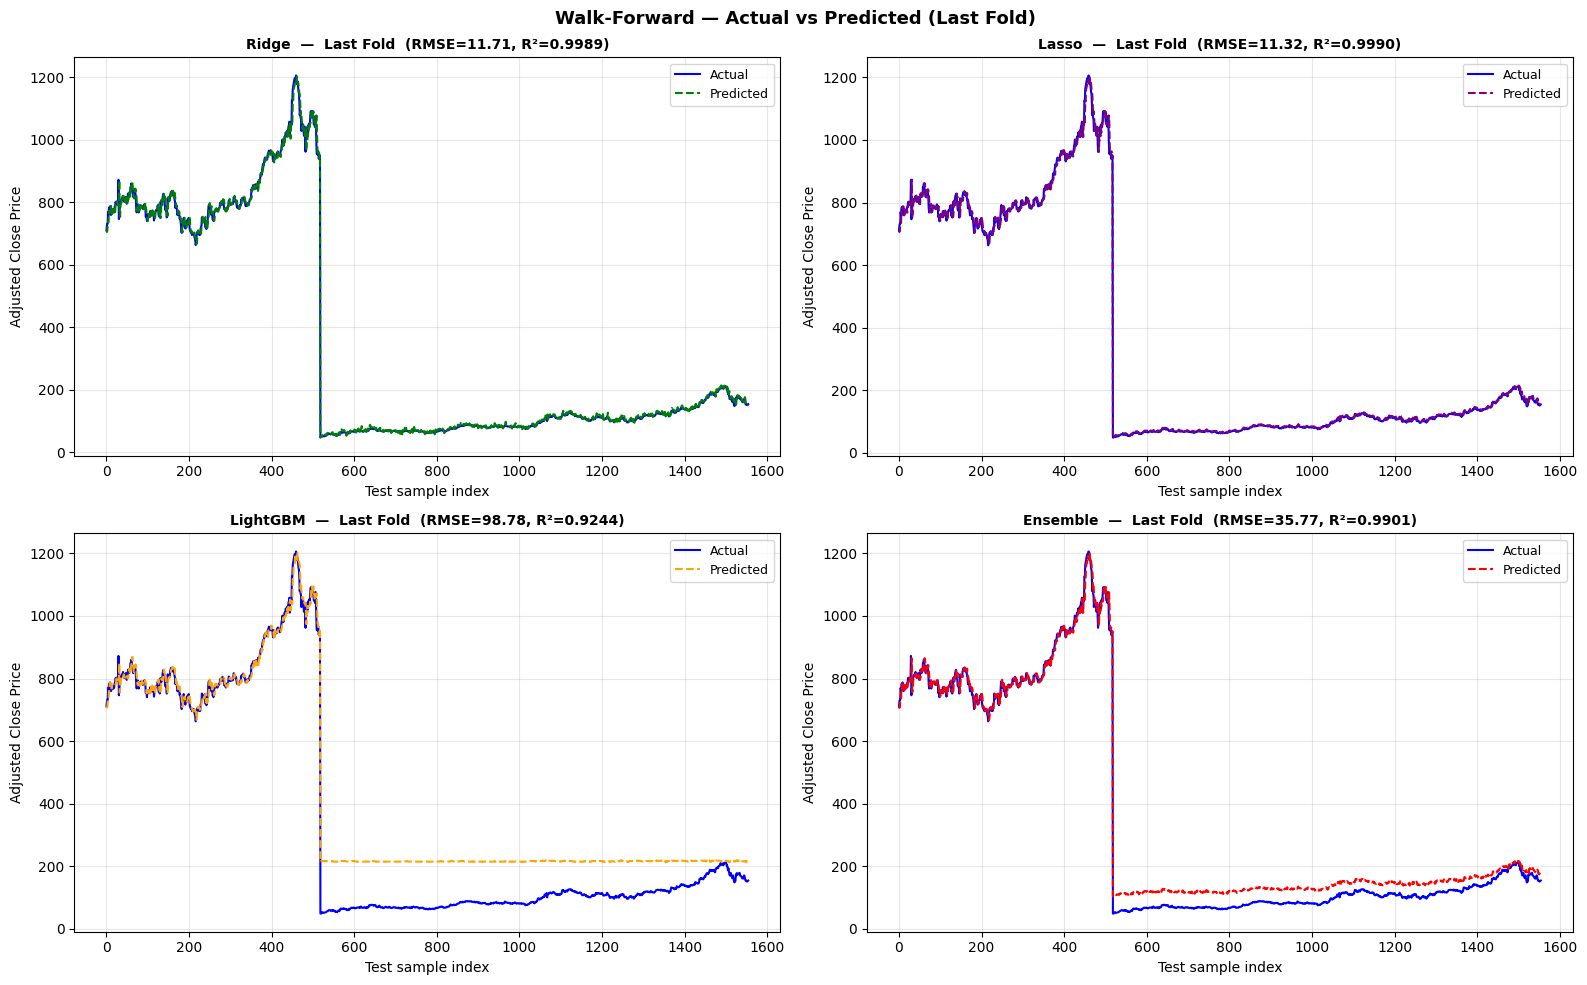


All forecasts generated.


In [10]:
"""
panel_models.py
---------------
Trains pooled models (Ridge, Lasso, LightGBM, and an ensemble) on a universe of stocks.
Uses lagged prices, RSI, Bollinger Bands, Stochastic Oscillator, Moving Averages,
and stock_id as features. All indicators computed on t-1 data (no look-ahead).
Evaluates out-of-sample performance.
"""

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# ==============================
# 1. Define stock universe
# ==============================
TICKERS = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS",
    "ICICIBANK.NS", "HINDUNILVR.NS", "ITC.NS", "SBIN.NS", "ASHOKLEY.NS"
]

# ==============================
# 2. Download and reshape data
# ==============================
print("Downloading data...")
df_raw = yf.download(TICKERS, period="5y", auto_adjust=False)

# df_raw has MultiIndex columns: (PriceType, Ticker)
# Stack the Ticker level into rows, then reset index
df_long = df_raw.stack(level=1).reset_index()
df_long.columns = ['Date', 'Ticker'] + list(df_long.columns[2:])

price_cols = ['Adj Close', 'Open', 'High', 'Low']
df_long = df_long[['Date', 'Ticker'] + price_cols]
df_long['Date'] = pd.to_datetime(df_long['Date'])
df_long = df_long.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Data shape: {df_long.shape}")
print(df_long.head())

# ==============================
# 3. Feature Engineering (per stock, all indicators on t-1 data)
# ==============================
# We'll process each ticker separately and concatenate – this avoids any groupby issues.

def compute_RSI(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window-1, adjust=False).mean()
    avg_loss = loss.ewm(com=window-1, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_bollinger_bands(series, window=20, num_std=2):
    sma = series.rolling(window).mean()
    std = series.rolling(window).std()
    upper = sma + num_std * std
    lower = sma - num_std * std
    pct_b = (series - lower) / (upper - lower)
    return upper, lower, pct_b

def compute_stochastic(high, low, close, k_window=14, d_window=3):
    lowest_low = low.rolling(k_window).min()
    highest_high = high.rolling(k_window).max()
    pct_k = (close - lowest_low) / (highest_high - lowest_low) * 100
    pct_d = pct_k.rolling(d_window).mean()
    return pct_k, pct_d

# List to collect processed dataframes
processed_dfs = []

for ticker in TICKERS:
    df_ticker = df_long[df_long['Ticker'] == ticker].copy()
    
    # Lag-1 columns
    for col in price_cols:
        col_name = col.replace(" ", "_")
        df_ticker[f'lag_1_{col_name}'] = df_ticker[col].shift(1)
    
    # RSI on lag-1 Adj Close
    df_ticker['RSI_14'] = compute_RSI(df_ticker['lag_1_Adj_Close'])
    
    # Bollinger Bands on lag-1 Adj Close
    upper, lower, pctb = compute_bollinger_bands(df_ticker['lag_1_Adj_Close'])
    df_ticker['BB_Upper'] = upper
    df_ticker['BB_Lower'] = lower
    df_ticker['BB_PctB'] = pctb
    
    # Stochastic on lag-1 High/Low/Adj Close
    k, d = compute_stochastic(df_ticker['lag_1_High'], df_ticker['lag_1_Low'], df_ticker['lag_1_Adj_Close'])
    df_ticker['Stoch_K'] = k
    df_ticker['Stoch_D'] = d
    
    # Moving averages on lag-1 Adj Close
    for window in [5, 10, 20, 50, 200]:
        df_ticker[f'SMA_{window}'] = df_ticker['lag_1_Adj_Close'].rolling(window).mean()
        df_ticker[f'EMA_{window}'] = df_ticker['lag_1_Adj_Close'].ewm(span=window, adjust=False).mean()
    
    # Additional odd lags (3,5,7,9) for all price columns
    for col in price_cols:
        col_name = col.replace(" ", "_")
        for i in range(3, 10, 2):
            df_ticker[f'lag_{i}_{col_name}'] = df_ticker[col].shift(i)
    
    processed_dfs.append(df_ticker)

# Combine all tickers
df_long = pd.concat(processed_dfs, ignore_index=True)

# Drop NaN rows (introduced by lags and rolling windows)
df_long.dropna(inplace=True)
df_long.reset_index(drop=True, inplace=True)

print(f"After feature engineering, shape: {df_long.shape}")

# ==============================
# 4. Prepare features and target
# ==============================
# Target: next day's Adj Close (shift -1 within each ticker)
df_long['target'] = df_long.groupby('Ticker')['Adj Close'].shift(-1)
df_long.dropna(subset=['target'], inplace=True)

# Build feature column list from everything generated above
lag_cols  = [c for c in df_long.columns if c.startswith('lag_')]
tech_cols = [
    'RSI_14',
    'BB_Upper', 'BB_Lower', 'BB_PctB',
    'Stoch_K',  'Stoch_D',
    'SMA_5',  'SMA_10',  'SMA_20',  'SMA_50',  'SMA_200',
    'EMA_5',  'EMA_10',  'EMA_20',  'EMA_50',  'EMA_200',
]
feature_cols = lag_cols + tech_cols   # used by linear models (no stock_id)

X = df_long[feature_cols].copy()
y = df_long['target']

# Add stock_id as a categorical feature (LightGBM only)
X['stock_id'] = df_long['Ticker'].astype('category')

# ==============================
# 5. Train/test split (chronological)
# ==============================
dates        = df_long['Date'].unique()
dates_sorted = np.sort(dates)
split_idx    = int(0.9 * len(dates_sorted))
train_dates  = dates_sorted[:split_idx]
test_dates   = dates_sorted[split_idx:]

train_mask = df_long['Date'].isin(train_dates)
test_mask  = df_long['Date'].isin(test_dates)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train dates: {train_dates[0]} to {train_dates[-1]}")
print(f"Test dates:  {test_dates[0]} to {test_dates[-1]}")

# ==============================
# 6. Evaluation helper
# ==============================
def evaluate(y_true, y_pred):
    return {
        "mae":  mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape": (np.abs((y_true - y_pred) / y_true)).mean() * 100,
        "r2":   r2_score(y_true, y_pred),
    }

# ==============================
# 7. Train models
# ==============================
results = {}

# ---- Ridge ----
print("\nTraining Ridge...")
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=1.0)),
])
ridge_pipeline.fit(X_train[feature_cols], y_train)
y_pred_ridge = ridge_pipeline.predict(X_test[feature_cols])
results['Ridge'] = evaluate(y_test, y_pred_ridge)

# ---- Lasso ----
print("Training Lasso...")
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(alpha=0.01, max_iter=10_000)),
])
lasso_pipeline.fit(X_train[feature_cols], y_train)
y_pred_lasso = lasso_pipeline.predict(X_test[feature_cols])
results['Lasso'] = evaluate(y_test, y_pred_lasso)

# ---- LightGBM (numeric stock_id as categorical) ----
print("Training LightGBM...")
lgb_feature_cols = feature_cols + ['stock_id']

X_train_lgb = X_train[lgb_feature_cols].copy()
X_test_lgb  = X_test[lgb_feature_cols].copy()
X_train_lgb['stock_id'] = X_train_lgb['stock_id'].cat.codes
X_test_lgb['stock_id']  = X_test_lgb['stock_id'].cat.codes

lgb_train = lgb.Dataset(X_train_lgb, y_train, categorical_feature=['stock_id'])
params = {
    'objective':        'regression',
    'metric':           'rmse',
    'boosting_type':    'gbdt',
    'num_leaves':       31,
    'learning_rate':    0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'verbose':          -1,
}
lgb_model   = lgb.train(params, lgb_train, num_boost_round=200)
y_pred_lgb  = lgb_model.predict(X_test_lgb)
results['LightGBM'] = evaluate(y_test, y_pred_lgb)

# ---- Ensemble (simple average) ----
y_pred_ensemble = (y_pred_ridge + y_pred_lasso + y_pred_lgb) / 3
results['Ensemble'] = evaluate(y_test, y_pred_ensemble)

# ==============================
# 8. Print results
# ==============================
print("\n" + "=" * 60)
print("Model Performance on Test Set")
print("=" * 60)
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"  MAE:  {metrics['mae']:.4f}")
    print(f"  RMSE: {metrics['rmse']:.4f}")
    print(f"  MAPE: {metrics['mape']:.2f}%")
    print(f"  R²:   {metrics['r2']:.4f}")

# ==============================
# 9. Feature importance (LightGBM)
# ==============================
lgb_feature_imp = pd.DataFrame({
    'feature':    X_train_lgb.columns,
    'importance': lgb_model.feature_importance(),
}).sort_values('importance', ascending=False)

print("\nTop-10 LightGBM Feature Importances:")
print(lgb_feature_imp.head(10).to_string(index=False))

# ==============================
# 10. Visualize predictions for one ticker (Matplotlib)
# ==============================
sample_ticker    = TICKERS[0]
ticker_test_mask = (df_long.loc[test_mask, 'Ticker'] == sample_ticker).values

if ticker_test_mask.any():
    dates_ticker  = df_long.loc[test_mask, 'Date'].values[ticker_test_mask]
    y_test_ticker = y_test.values[ticker_test_mask]

    plt.figure(figsize=(12, 6))
    plt.plot(dates_ticker, y_test_ticker,
             label='Actual', color='blue', linewidth=2)
    plt.plot(dates_ticker, y_pred_ridge[ticker_test_mask],
             label='Ridge', linestyle=':', color='green')
    plt.plot(dates_ticker, y_pred_lgb[ticker_test_mask],
             label='LightGBM', linestyle='-.', color='orange')
    plt.plot(dates_ticker, y_pred_ensemble[ticker_test_mask],
             label='Ensemble', linestyle='--', color='red')
    plt.title(f'{sample_ticker} – Actual vs Predictions (Test Set)')
    plt.xlabel('Date')
    plt.ylabel('Adjusted Close Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==============================
# 11. Visualize feature importance (Matplotlib)
# ==============================
top_features = lgb_feature_imp.head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 20 LightGBM Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ==============================
# 12. Recursive forecasting for next 5 days for each stock
# ==============================
print("\n" + "=" * 60)
print("Recursive 5-day forecasts using ensemble model")
print("=" * 60)

def build_features(price_list, open_list, high_list, low_list, ticker):
    adj_s  = pd.Series(price_list, dtype=float)
    open_s = pd.Series(open_list,  dtype=float)
    high_s = pd.Series(high_list,  dtype=float)
    low_s  = pd.Series(low_list,   dtype=float)

    n = len(adj_s)
    feature_dict = {}

    series_map = {
        'Adj_Close': adj_s,
        'Open':      open_s,
        'High':      high_s,
        'Low':       low_s,
    }
    for col_name, series in series_map.items():
        for i in [1, 3, 5, 7, 9]:
            key = f'lag_{i}_{col_name}'
            if key in feature_cols:
                feature_dict[key] = series.iloc[-i] if n >= i else np.nan

    feature_dict['RSI_14'] = compute_RSI(adj_s).iloc[-1]
    bb_upper, bb_lower, bb_pctb = compute_bollinger_bands(adj_s)
    feature_dict['BB_Upper'] = bb_upper.iloc[-1]
    feature_dict['BB_Lower'] = bb_lower.iloc[-1]
    feature_dict['BB_PctB']  = bb_pctb.iloc[-1]
    pct_k, pct_d = compute_stochastic(high_s, low_s, adj_s)
    feature_dict['Stoch_K'] = pct_k.iloc[-1]
    feature_dict['Stoch_D'] = pct_d.iloc[-1]
    for w in [5, 10, 20, 50, 200]:
        feature_dict[f'SMA_{w}'] = adj_s.rolling(w).mean().iloc[-1]
        feature_dict[f'EMA_{w}'] = adj_s.ewm(span=w, adjust=False).mean().iloc[-1]

    features_df = pd.DataFrame([feature_dict])[feature_cols].copy()
    features_df['stock_id'] = pd.Categorical([ticker])
    return features_df

def ensemble_predict(features_df, ticker_cat_codes):
    X_num = features_df[feature_cols]
    pred_ridge = ridge_pipeline.predict(X_num)[0]
    pred_lasso = lasso_pipeline.predict(X_num)[0]
    X_lgb = features_df[lgb_feature_cols].copy()
    X_lgb['stock_id'] = (
        X_lgb['stock_id']
        .astype(str)
        .map(ticker_cat_codes)
        .fillna(-1)
        .astype(int)
    )
    pred_lgb = lgb_model.predict(X_lgb)[0]
    return (pred_ridge + pred_lasso + pred_lgb) / 3

ticker_cat_codes = dict(zip(X_train['stock_id'].cat.categories,
                            range(len(X_train['stock_id'].cat.categories))))

ensemble_rmse = results['Ensemble']['rmse']
print(f"Ensemble RMSE on test set: {ensemble_rmse:.4f}")

forecasts = {}
for ticker in TICKERS:
    ticker_data = df_raw.xs(ticker, level=1, axis=1).dropna()
    actual_prices = ticker_data['Adj Close'].tolist()
    actual_opens  = ticker_data['Open'].tolist()
    actual_highs  = ticker_data['High'].tolist()
    actual_lows   = ticker_data['Low'].tolist()

    if len(actual_prices) < 200:
        print(f"Skipping {ticker}: insufficient history ({len(actual_prices)} rows).")
        continue

    last_date = ticker_data.index[-1]
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=5)
    last_open = actual_opens[-1]
    last_high = actual_highs[-1]
    last_low  = actual_lows[-1]

    price_list = actual_prices.copy()
    open_list  = actual_opens.copy()
    high_list  = actual_highs.copy()
    low_list   = actual_lows.copy()
    predictions = []

    for step in range(5):
        features_df = build_features(price_list, open_list, high_list, low_list, ticker)
        next_price = ensemble_predict(features_df, ticker_cat_codes)
        predictions.append(next_price)
        price_list.append(next_price)
        open_list.append(last_open)
        high_list.append(last_high)
        low_list.append(last_low)

    forecasts[ticker] = {
        'dates': future_dates,
        'predictions': predictions,
        'last_actual_date': last_date,
        'actual_prices': actual_prices,
        'actual_dates': ticker_data.index.tolist(),
    }
    print(f"\n{ticker} – Next 5 trading-day predictions:")
    for date, price in zip(future_dates, predictions):
        print(f"  {date.strftime('%Y-%m-%d')}: {price:.2f}")

# ==============================
# 13. Visualize forecasts with uncertainty bands (Matplotlib)
# ==============================
n_stocks = len(forecasts)
fig, axes = plt.subplots(n_stocks, 1, figsize=(14, 5 * n_stocks), sharex=False)
if n_stocks == 1:
    axes = [axes]

for idx, (ticker, fcast) in enumerate(forecasts.items()):
    ax = axes[idx]
    actual_prices = fcast['actual_prices']
    actual_dates  = fcast['actual_dates']
    plot_prices   = actual_prices[-30:]
    plot_dates    = actual_dates[-30:]

    ax.plot(plot_dates, plot_prices, label='Actual', color='blue', linewidth=2)

    future_dates = fcast['dates']
    preds        = fcast['predictions']
    upper_band   = [p + ensemble_rmse for p in preds]
    lower_band   = [p - ensemble_rmse for p in preds]

    ax.errorbar(future_dates, preds, yerr=ensemble_rmse,
                fmt='ro--', capsize=5, markersize=7, linewidth=2,
                label=f'Forecast ±1 RMSE ({ensemble_rmse:.2f})')
    ax.fill_between(future_dates, lower_band, upper_band,
                    color='red', alpha=0.15, label='±1 RMSE band')

    for date, price, _ in zip(future_dates, preds, upper_band):
        ax.annotate(f'{price:.1f}', xy=(date, price), xytext=(0, 10),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold', color='darkred',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))

    ax.axvline(x=fcast['last_actual_date'], color='grey',
               linestyle=':', linewidth=1.2, alpha=0.8)
    y_label_pos = min(plot_prices + preds)
    ax.text(fcast['last_actual_date'], y_label_pos, ' last\n actual',
            fontsize=7, color='grey', va='bottom')
    ax.set_title(f'{ticker} – Last 30 Days + 5-Day Forecast', fontsize=12, fontweight='bold')
    ax.set_ylabel('Adjusted Close Price')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

axes[-1].set_xlabel('Date')
plt.suptitle('Recursive 5-Day Ensemble Forecasts', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# ==============================
# 14. Walk-Forward Validation (all 4 models)
# ==============================
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

fold_metrics = {m: [] for m in ('Ridge', 'Lasso', 'LightGBM', 'Ensemble')}
fold_predictions = {m: [] for m in ('Ridge', 'Lasso', 'LightGBM', 'Ensemble')}

X_num  = X[feature_cols].copy()
X_full = X[lgb_feature_cols].copy()
X_full['stock_id'] = X_full['stock_id'].cat.codes

print("\n" + "=" * 60)
print(f"Walk-Forward Validation  ({N_SPLITS} folds)")
print("=" * 60)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_num)):
    Xn_tr, Xn_te = X_num.iloc[train_idx], X_num.iloc[test_idx]
    Xf_tr, Xf_te = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_tr, y_te   = y.iloc[train_idx], y.iloc[test_idx]

    ridge_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
    ridge_pipe.fit(Xn_tr, y_tr)
    pred_ridge = ridge_pipe.predict(Xn_te)

    lasso_pipe = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.01, max_iter=10_000))])
    lasso_pipe.fit(Xn_tr, y_tr)
    pred_lasso = lasso_pipe.predict(Xn_te)

    lgb_tr = lgb.Dataset(Xf_tr, y_tr, categorical_feature=['stock_id'])
    lgb_params = {'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
                  'num_leaves': 31, 'learning_rate': 0.05, 'feature_fraction': 0.9,
                  'bagging_fraction': 0.8, 'bagging_freq': 5, 'verbose': -1}
    lgb_fold = lgb.train(lgb_params, lgb_tr, num_boost_round=200)
    pred_lgb = lgb_fold.predict(Xf_te)

    pred_ensemble = (pred_ridge + pred_lasso + pred_lgb) / 3
    preds_map = {'Ridge': pred_ridge, 'Lasso': pred_lasso, 'LightGBM': pred_lgb, 'Ensemble': pred_ensemble}

    print(f"\nFold {fold+1}  (train rows: {len(train_idx):,}  |  test rows: {len(test_idx):,})")
    print(f"  {'Model':<12} {'MAE':>10} {'RMSE':>10} {'MAPE':>10} {'R²':>8}")
    print(f"  {'-'*52}")

    for model_name, pred in preds_map.items():
        m = evaluate(y_te, pred)
        fold_metrics[model_name].append(m)
        fold_predictions[model_name].append((y_te.values, pred))
        print(f"  {model_name:<12} {m['mae']:>10.4f} {m['rmse']:>10.4f} {m['mape']:>9.2f}% {m['r2']:>8.4f}")

print("\n" + "=" * 60)
print("Average metrics across all folds")
print("=" * 60)
print(f"  {'Model':<12} {'MAE':>10} {'RMSE':>10} {'MAPE':>10} {'R²':>8}")
print(f"  {'-'*52}")
for model_name in ('Ridge', 'Lasso', 'LightGBM', 'Ensemble'):
    folds = fold_metrics[model_name]
    avg = {k: float(np.mean([f[k] for f in folds])) for k in folds[0]}
    print(f"  {model_name:<12} {avg['mae']:>10.4f} {avg['rmse']:>10.4f} {avg['mape']:>9.2f}% {avg['r2']:>8.4f}")

# Plot RMSE and R² per fold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Ridge': 'green', 'Lasso': 'purple', 'LightGBM': 'orange', 'Ensemble': 'red'}
folds_x = range(1, N_SPLITS+1)

ax = axes[0]
for model_name, color in colors.items():
    rmse_per_fold = [m['rmse'] for m in fold_metrics[model_name]]
    ax.plot(folds_x, rmse_per_fold, marker='o', label=model_name, color=color, linewidth=2, markersize=7)
ax.set_title('RMSE per Fold', fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(list(folds_x))

ax = axes[1]
for model_name, color in colors.items():
    r2_per_fold = [m['r2'] for m in fold_metrics[model_name]]
    ax.plot(folds_x, r2_per_fold, marker='s', label=model_name, color=color, linewidth=2, markersize=7)
ax.set_title('R² per Fold', fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(list(folds_x))

plt.suptitle('Walk-Forward Validation — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot last fold actual vs predicted for each model
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for ax_idx, (model_name, color) in enumerate(colors.items()):
    y_true_last, y_pred_last = fold_predictions[model_name][-1]
    ax = axes[ax_idx]
    ax.plot(y_true_last, label='Actual', color='blue', linewidth=1.5)
    ax.plot(y_pred_last, label='Predicted', color=color, linewidth=1.5, linestyle='--')
    ax.set_title(f'{model_name}  —  Last Fold  (RMSE={fold_metrics[model_name][-1]["rmse"]:.2f}, R²={fold_metrics[model_name][-1]["r2"]:.4f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Test sample index')
    ax.set_ylabel('Adjusted Close Price')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Walk-Forward — Actual vs Predicted (Last Fold)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAll forecasts generated.")